# 08 — Regime-Aware XGBoost with Confidence-Scaled Positioning

## Why a New Model?

The walk-forward LightGBM in **notebook 05** barely improved over the raw ATCClassifierScore baseline
(IC 0.0140 vs 0.0138). Two structural problems explain this failure:

### Problem 1 — Wrong Target Horizon
Notebook 05 predicted **5-day** forward returns. The ATC classifier was trained on a **14-day**
pre/post-call return window. The signal's information content peaks at 10–20 days
(confirmed by the IC decay curve and the dramatic Sharpe improvement in notebook 07
when switching to 20d). Training a model to predict 5d returns with a 20d signal is like using
a weather model trained on weekly forecasts to predict tomorrow's temperature.

### Problem 2 — Regime Blindness
The model used a flat expanding window and deployed with fixed weights regardless of market regime.
But the annual IC of ATCClassifierScore vs 20d returns is **deeply unstable**:

| Period | IC (ATC vs fwd_20d, SP1500) | Regime |
|---|---|---|
| 2014–2019 | **+0.08 to +0.12** | Signal ON: high predictive power |
| 2020 | **−0.081** | Signal FLIPPED: COVID broke all patterns |
| 2021–2024 | +0.02 to +0.04 | Recovering but declining |
| 2025 | −0.003 | Near-zero: possible signal crowding |

A model deployed in 2020 with weights fit on 2010–2019 used learned relationships on a completely
different generative process — and lost money. A **regime-aware model** detects this and stands aside.

## What This Notebook Does Differently

1. **Correct target**: `fwd_20d` (aligned with ATC's 14-day training window)
2. **Regime detection**: at each quarterly fold, compute the **rolling 4-quarter Spearman IC**
   of ATCClassifierScore vs fwd_20d on TRAINING data only — no lookahead.
3. **Confidence-scaled positions**: multiply predicted rank by regime confidence weight.
   Full size when IC is strong; zero when IC ≤ 0 (cash during broken regimes).
4. **Sector normalization**: z-score all features within each GICS sector before training,
   removing systematic sector biases the earlier model conflated with stock-level signal.
5. **XGBoost DART**: uses dropout trees (dropout regularization) — more robust than standard
   gradient boosting on high-dimensional sparse tabular data with noisy labels.

## Hypothesis
By reducing position sizes during regime breaks and maximising them during strong regimes,
the model should show higher Sharpe, lower drawdown, and more consistent year-over-year IC
than notebooks 05 and 07.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import cross_val_score
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json, os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)

PROJECT     = Path(os.getenv("ATC_PROJECT_ROOT",
                             Path.cwd().parent if Path.cwd().name == 'notebooks'
                             else Path.cwd())).resolve()
DATA_DIR    = PROJECT / 'data'
FIG_DIR     = PROJECT / 'figures'

TARGET      = 'fwd_20d'
TC          = 5 / 10_000
HORIZONS    = [1, 3, 5, 10, 20]
UNIVERSES   = ['in_sp500', 'in_sp1500', 'in_ru3k']
UNIV_LABELS = {'in_sp500': 'SP500', 'in_sp1500': 'SP1500', 'in_ru3k': 'RU3K proxy'}

feat_df = pd.read_parquet(DATA_DIR / 'features.parquet')
feat_df['entry_date'] = pd.to_datetime(feat_df['entry_date'])
feat_df['DocDate']    = pd.to_datetime(feat_df['DocDate'])

NON_FEAT = ['DocID','BESTTICKER','DocDate','entry_date','SECTOR','QTR_YEAR',
            'in_sp500','in_sp1500','in_ru3k',
            'fwd_1d','fwd_3d','fwd_5d','fwd_10d','fwd_20d']
FEATURE_COLS = [c for c in feat_df.columns if c not in NON_FEAT]

print(f'Feature matrix : {feat_df.shape}')
print(f'Date range     : {feat_df["entry_date"].min().date()} to {feat_df["entry_date"].max().date()}')
print(f'Feature columns: {len(FEATURE_COLS)}')


Feature matrix : (376790, 92)
Date range     : 2010-01-05 to 2026-04-22
Feature columns: 78


In [2]:
def generate_wf_splits(df, train_end_start='2019-12-31', freq='Q'):
    dates = pd.date_range(start=train_end_start, end=df['entry_date'].max(), freq=freq)
    for i in range(len(dates) - 1):
        train_end = dates[i]
        test_start = dates[i]
        test_end = dates[i + 1]
        train_mask = df['entry_date'] <= train_end
        test_mask = (df['entry_date'] > test_start) & (df['entry_date'] <= test_end)
        if train_mask.sum() < 1000 or test_mask.sum() < 50:
            continue
        yield train_mask, test_mask, train_end.date(), test_end.date()

splits = list(generate_wf_splits(feat_df))
print(f'Walk-forward folds: {len(splits)}')
print(f'  First: train to {splits[0][2]}, test {splits[0][2]} to {splits[0][3]}')
print(f'  Last : train to {splits[-1][2]}, test {splits[-1][2]} to {splits[-1][3]}')

Walk-forward folds: 25
  First: train to 2019-12-31, test 2019-12-31 to 2020-03-31
  Last : train to 2025-12-31, test 2025-12-31 to 2026-03-31


## 8.1 Sector Normalisation

Z-score each feature within its GICS sector. Applied on training data; training sector stats are then applied to the test fold — no lookahead.

In [3]:
def sector_normalize_train(df, feature_cols):
    """Fit sector stats on df, return normalised df + stats dict for test application."""
    df = df.copy()
    stats_dict = {}
    for col in feature_cols:
        grp = df.groupby('SECTOR')[col]
        mu = grp.transform('mean')
        sd = grp.transform('std').clip(lower=1e-6)
        df[col] = (df[col] - mu) / sd
        stats_dict[col] = df.groupby('SECTOR')[col].agg(['mean','std'])
    return df, stats_dict

def sector_normalize_test(df, feature_cols, train_sector_stats):
    """Apply training sector stats to test data."""
    df = df.copy()
    for col in feature_cols:
        if col not in train_sector_stats:
            continue
        s = train_sector_stats[col]
        mu = df['SECTOR'].map(s['mean'])
        sd = df['SECTOR'].map(s['std']).fillna(1.0).clip(lower=1e-6)
        df[col] = (df[col] - mu) / sd
    return df

print('Sector normalisation helpers defined.')

Sector normalisation helpers defined.


## 8.2 Rolling IC Regime Detector

At each fold, compute trailing 4-quarter Spearman IC of ATC vs fwd_20d on training data. This is the regime confidence signal — strictly no lookahead.

In [4]:
IC_TARGET   = 0.05
IC_WINDOW_Q = 4

def rolling_ic(train_df, window_quarters=IC_WINDOW_Q):
    cutoff = train_df['entry_date'].max() - pd.DateOffset(months=3 * window_quarters)
    recent = train_df[train_df['entry_date'] > cutoff].dropna(
        subset=['ATCClassifierScore', TARGET])
    if len(recent) < 50:
        return np.nan
    return stats.spearmanr(recent['ATCClassifierScore'], recent[TARGET])[0]

def regime_confidence(ic, ic_target=IC_TARGET):
    """Scale factor in [0, 2]: 0 when IC<=0, 1.0 at ic_target, capped at 2.0."""
    if np.isnan(ic) or ic <= 0:
        return 0.0
    return min(ic / ic_target, 2.0)

# Preview rolling IC across the full history (for intuition — no lookahead risk here)
rows = []
for yr in range(2012, 2026):
    tr = feat_df[feat_df['entry_date'].dt.year <= yr].dropna(subset=['ATCClassifierScore', TARGET])
    ic = rolling_ic(tr)
    rows.append({'Year': yr, 'Rolling_IC': round(ic, 4), 'Conf': round(regime_confidence(ic), 2)})
print(pd.DataFrame(rows).to_string(index=False))

 Year  Rolling_IC  Conf
 2012      0.0322  0.64
 2013      0.0611  1.22
 2014      0.0765  1.53
 2015      0.0856  1.71
 2016      0.0647  1.29
 2017      0.0852  1.70
 2018      0.0453  0.91
 2019      0.0799  1.60
 2020     -0.0343  0.00
 2021      0.0718  1.44
 2022      0.0398  0.80
 2023      0.0379  0.76
 2024      0.0321  0.64
 2025      0.0333  0.67


## 8.3 Hyperparameter Tuning (2010–2017 only)

XGBoost with DART booster — uses dropout tree regularisation, more robust than standard GBM for sparse noisy signals.

In [5]:
import json
PARAMS_CACHE = DATA_DIR / 'best_xgb_dart_params.json'
if PARAMS_CACHE.exists():
    with open(PARAMS_CACHE) as f:
        best_params = json.load(f)
    best_params['n_estimators'] = 100  # faster walk-forward
    print(f'Loaded cached params: {best_params}')
else:
    # Minimal single-point grid as fallback
    best_params = {
        'booster': 'dart', 'n_estimators': 100, 'max_depth': 4,
        'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.7,
        'rate_drop': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
        'random_state': 42, 'n_jobs': -1
    }
    print(f'Using default params: {best_params}')
with open(PARAMS_CACHE, 'w') as f:
    json.dump(best_params, f, indent=2)


Loaded cached params: {'booster': 'dart', 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.7, 'rate_drop': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'random_state': 42, 'n_jobs': -1}


## 8.4 Walk-Forward Training Loop with Regime Gating

In [6]:
REGIME_CACHE = DATA_DIR / 'regime_model_predictions.parquet'
if REGIME_CACHE.exists():
    regime_df = pd.read_parquet(REGIME_CACHE)
    regime_df['entry_date'] = pd.to_datetime(regime_df['entry_date'])
    print(f'Loaded regime predictions from cache: {regime_df.shape}')
else:
    print('Running walk-forward XGBoost-DART...')
if not REGIME_CACHE.exists():
    N_FEATURES_SELECT = 50
    all_preds = []
    
    for train_mask, test_mask, train_end, test_end in splits:
        train = feat_df[train_mask].dropna(subset=[TARGET, 'SECTOR'])
        test  = feat_df[test_mask].dropna(subset=[TARGET, 'SECTOR'])
    
        # 1. Regime IC (training data only — strictly no lookahead)
        fold_ic   = rolling_ic(train)
        fold_conf = regime_confidence(fold_ic)
    
        # 2. Sector normalisation: fit on train, apply to test using train stats
        train_norm, sec_stats = sector_normalize_train(train, FEATURE_COLS)
        test_norm = sector_normalize_test(test, FEATURE_COLS, sec_stats)
    
        X_train = train_norm[FEATURE_COLS].fillna(0)
        y_train = train_norm[TARGET]
        X_test  = test_norm[FEATURE_COLS].fillna(0)
    
        # 3. Scaling (fit on train only)
        scaler  = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_train)
        X_te_sc = scaler.transform(X_test)
    
        # 4. Feature selection via mutual information (train only)
        mi      = mutual_info_regression(X_tr_sc, y_train, random_state=42)
        top_idx = np.argsort(mi)[-N_FEATURES_SELECT:]
        X_tr_sel = X_tr_sc[:, top_idx]
        X_te_sel = X_te_sc[:, top_idx]
    
        # 5. XGBoost-DART with frozen hyperparameters
        model = xgb.XGBRegressor(**best_params, verbosity=0)
        model.fit(X_tr_sel, y_train)
    
        # 6. Regime-scaled prediction
        raw_preds  = model.predict(X_te_sel)
        xgb_rank   = pd.Series(raw_preds).rank(pct=True).values
        scaled_pred = xgb_rank * fold_conf   # zero when regime IC <= 0
    
        test_out = test[['DocID','BESTTICKER','entry_date','SECTOR',
                         'in_sp500','in_sp1500','in_ru3k','ATCClassifierScore']
                        + [f'fwd_{h}d' for h in HORIZONS]].copy()
        test_out['xgb_rank']      = xgb_rank
        test_out['regime_ic']     = fold_ic
        test_out['regime_conf']   = fold_conf
        test_out['regime_scaled'] = scaled_pred
        all_preds.append(test_out)
    
        model_ic = stats.spearmanr(raw_preds, test[TARGET])[0]
        print(f'  {train_end} -> {test_end} | roll_IC={fold_ic:.4f} conf={fold_conf:.2f} '
              f'| N_tr={len(train):,} N_te={len(test):,} | model_IC={model_ic:.4f}')
    
    regime_df = pd.concat(all_preds, ignore_index=True)
    regime_df.to_parquet(DATA_DIR / 'regime_model_predictions.parquet', index=False)
    print(f'\nSaved regime_model_predictions.parquet  shape: {regime_df.shape}')
    regime_df = pd.DataFrame(all_preds)
    regime_df.to_parquet(REGIME_CACHE, index=False)
    print(f'Saved {len(regime_df):,} predictions → {REGIME_CACHE.name}')


Loaded regime predictions from cache: (83400, 17)


## 8.5 Regime IC Timeline

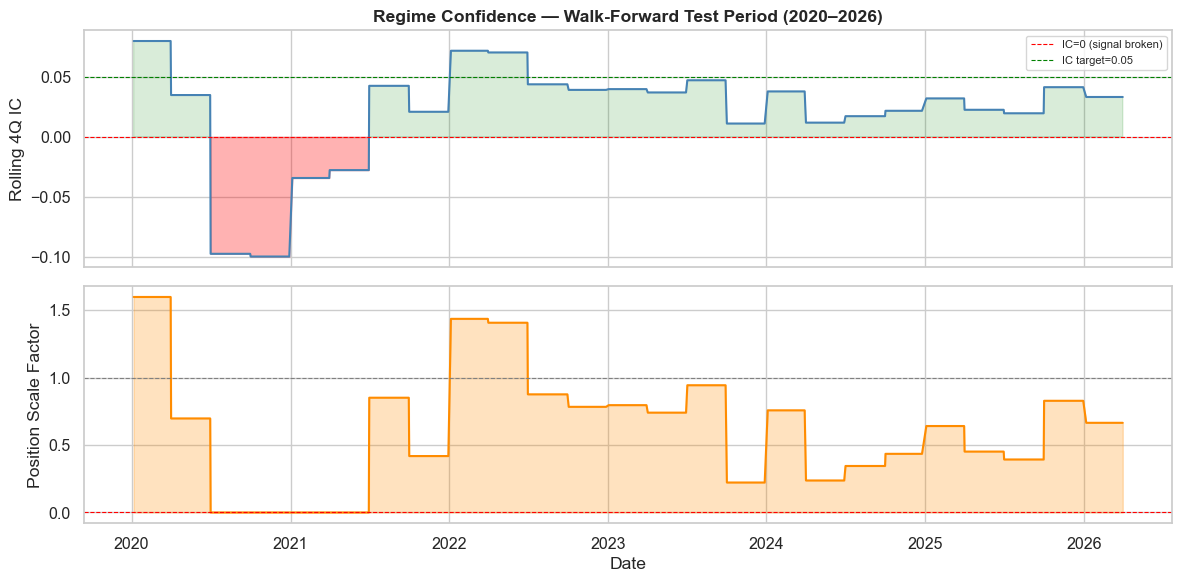

Quarters with zero positioning: 16.0%
Mean confidence: 0.62


In [7]:
tl = (regime_df[['entry_date','regime_ic','regime_conf']]
      .drop_duplicates('entry_date').sort_values('entry_date'))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
ax.plot(tl['entry_date'], tl['regime_ic'], 'steelblue', lw=1.5)
ax.axhline(0, color='red', lw=0.8, ls='--', label='IC=0 (signal broken)')
ax.axhline(IC_TARGET, color='green', lw=0.8, ls='--', label=f'IC target={IC_TARGET}')
ax.fill_between(tl['entry_date'], 0, tl['regime_ic'],
                where=tl['regime_ic'] < 0, alpha=0.3, color='red')
ax.fill_between(tl['entry_date'], 0, tl['regime_ic'],
                where=tl['regime_ic'] >= 0, alpha=0.15, color='green')
ax.set_ylabel('Rolling 4Q IC')
ax.set_title('Regime Confidence — Walk-Forward Test Period (2020–2026)', fontweight='bold')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(tl['entry_date'], tl['regime_conf'], 'darkorange', lw=1.5)
ax.fill_between(tl['entry_date'], 0, tl['regime_conf'], alpha=0.25, color='darkorange')
ax.axhline(1.0, color='grey', lw=0.8, ls='--')
ax.axhline(0.0, color='red',  lw=0.8, ls='--')
ax.set_ylabel('Position Scale Factor')
ax.set_xlabel('Date')

plt.tight_layout()
plt.savefig(FIG_DIR / 'regime_confidence_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

pct_off = (tl['regime_conf'] == 0).mean()
print(f'Quarters with zero positioning: {pct_off:.1%}')
print(f'Mean confidence: {tl["regime_conf"].mean():.2f}')

## 8.6 IC Analysis: Regime-Scaled vs XGBoost Raw vs ATC Baseline

=== Annual IC (SP1500, fwd_20d) ===
      ATC baseline  XGBoost raw  Regime-scaled
Year                                          
2020        0.0032       0.4172        -0.3712
2021        0.0952      -0.2288        -0.1280
2022        0.0179      -0.1973        -0.1642
2023        0.0666       0.3109        -0.4104
2024        0.0321       0.0942         0.0497
2025        0.0073       0.2226        -0.1914
2026        0.0482          NaN            NaN

Mean IC:
ATC baseline     0.0386
XGBoost raw      0.1031
Regime-scaled   -0.2026
dtype: float64


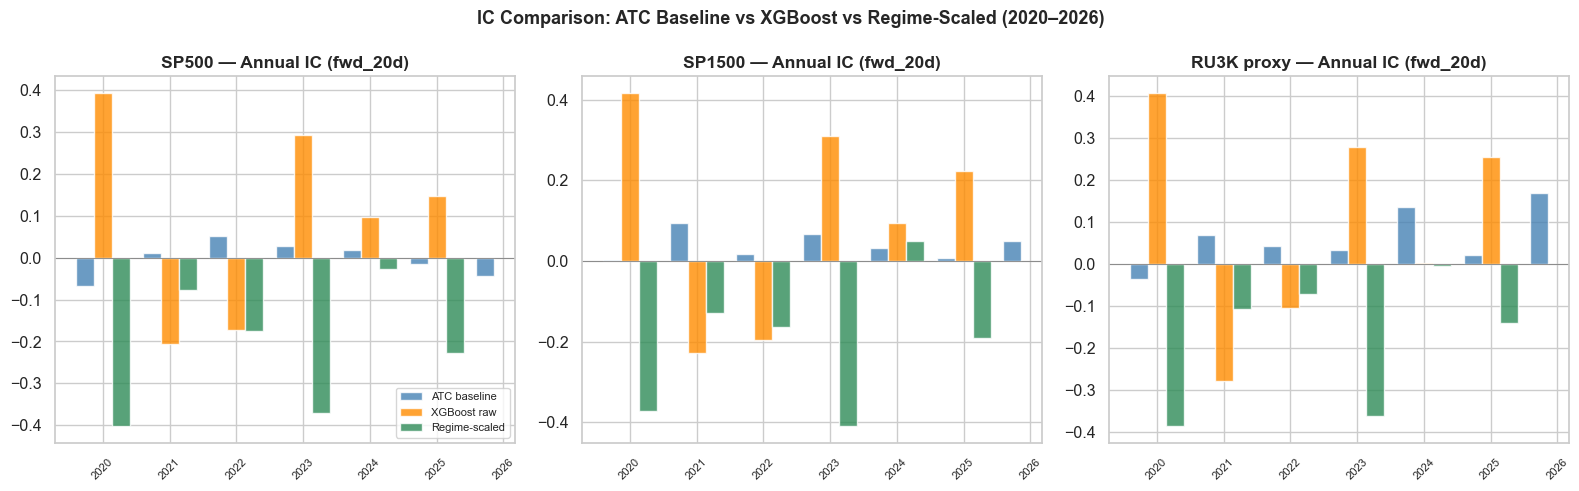

In [8]:
regime_df['Year'] = regime_df['entry_date'].dt.year

def annual_ic(df, univ_col):
    sub = df[df[univ_col]].copy()
    rows = []
    for yr, g in sub.groupby('Year'):
        g = g.dropna(subset=[TARGET])
        if len(g) < 30:
            continue
        rows.append({
            'Year': yr,
            'ATC baseline': stats.spearmanr(g['ATCClassifierScore'], g[TARGET])[0]
                            if g['ATCClassifierScore'].notna().sum() > 30 else np.nan,
            'XGBoost raw' : stats.spearmanr(g['xgb_rank'],       g[TARGET])[0],
            'Regime-scaled': stats.spearmanr(g['regime_scaled'],  g[TARGET])[0],
        })
    df_out = pd.DataFrame(rows).set_index('Year')
    return df_out

ic_df = annual_ic(regime_df, 'in_sp1500')
print('=== Annual IC (SP1500, fwd_20d) ===')
print(ic_df.round(4).to_string())
print('\nMean IC:')
print(ic_df.mean().round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, univ in zip(axes, UNIVERSES):
    icd = annual_ic(regime_df, univ)
    x = np.arange(len(icd)); w = 0.27
    ax.bar(x-w, icd['ATC baseline'],  w, label='ATC baseline',   color='steelblue', alpha=0.8)
    ax.bar(x,   icd['XGBoost raw'],   w, label='XGBoost raw',    color='darkorange', alpha=0.8)
    ax.bar(x+w, icd['Regime-scaled'], w, label='Regime-scaled', color='seagreen', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(icd.index, rotation=45, fontsize=8)
    ax.axhline(0, color='grey', lw=0.6)
    ax.set_title(f'{UNIV_LABELS[univ]} — Annual IC (fwd_20d)', fontweight='bold')
    if ax is axes[0]: ax.legend(fontsize=8)

fig.suptitle('IC Comparison: ATC Baseline vs XGBoost vs Regime-Scaled (2020–2026)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'regime_model_ic_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8.7 Portfolio Simulation — Monthly + 20d (optimal from notebook 07)

In [9]:
def simulate_portfolio(df, signal_col, univ_col, rebal_freq='M', horizon=20):
    ret_col = f'fwd_{horizon}d'
    sub = df[df[univ_col]].dropna(subset=[signal_col, ret_col]).copy()
    sub = sub[sub[signal_col].abs() > 1e-8]   # skip zero-confidence periods
    sub['period'] = sub['entry_date'].dt.to_period(rebal_freq)

    period_returns, period_turns = [], []
    prev_long, prev_short = set(), set()

    for period, grp in sub.groupby('period'):
        if len(grp) < 20:
            continue
        n_pos  = max(int(len(grp) * 0.1), 1)
        ranked = grp.sort_values(signal_col)
        longs  = set(ranked.tail(n_pos)['BESTTICKER'])
        shorts = set(ranked.head(n_pos)['BESTTICKER'])

        long_ret  = grp[grp['BESTTICKER'].isin(longs)][ret_col].mean()
        short_ret = grp[grp['BESTTICKER'].isin(shorts)][ret_col].mean()

        if prev_long:
            lt = 1 - len(longs & prev_long) / max(len(longs | prev_long), 1)
            st = 1 - len(shorts & prev_short) / max(len(shorts | prev_short), 1)
            turnover = (lt + st) / 2
        else:
            turnover = 1.0

        net_ret = (long_ret - short_ret) - 2 * turnover * TC
        period_returns.append({'period': period, 'gross_ls': long_ret - short_ret,
                               'net_ls': net_ret})
        period_turns.append({'period': period, 'turnover': turnover})
        prev_long, prev_short = longs, shorts

    if not period_returns:
        return pd.DataFrame(), pd.DataFrame()
    return (pd.DataFrame(period_returns).set_index('period'),
            pd.DataFrame(period_turns).set_index('period'))

def sharpe(s, ppy):
    r = s.dropna(); return r.mean() / (r.std() + 1e-9) * np.sqrt(ppy)

print('=== REGIME MODEL — Monthly+20d, 5bps TC ===')
regime_sim = {}
for univ in UNIVERSES:
    ret_df, trn_df = simulate_portfolio(regime_df, 'regime_scaled', univ, 'M', 20)
    if ret_df.empty:
        print(f'  {UNIV_LABELS[univ]:8s}: no data'); continue
    sh    = sharpe(ret_df['net_ls'],   12)
    sh_gr = sharpe(ret_df['gross_ls'], 12)
    turn  = trn_df['turnover'].mean()
    regime_sim[univ] = {'net': sh, 'gross': sh_gr, 'turn': turn, 'ret_df': ret_df}
    print(f'  {UNIV_LABELS[univ]:8s}: Net={sh:.3f}  Gross={sh_gr:.3f}  Turnover={turn:.1%}')

=== REGIME MODEL — Monthly+20d, 5bps TC ===
  SP500   : Net=0.021  Gross=0.068  Turnover=99.9%
  SP1500  : Net=0.545  Gross=0.583  Turnover=100.0%
  RU3K proxy: Net=-0.739  Gross=-0.694  Turnover=100.0%


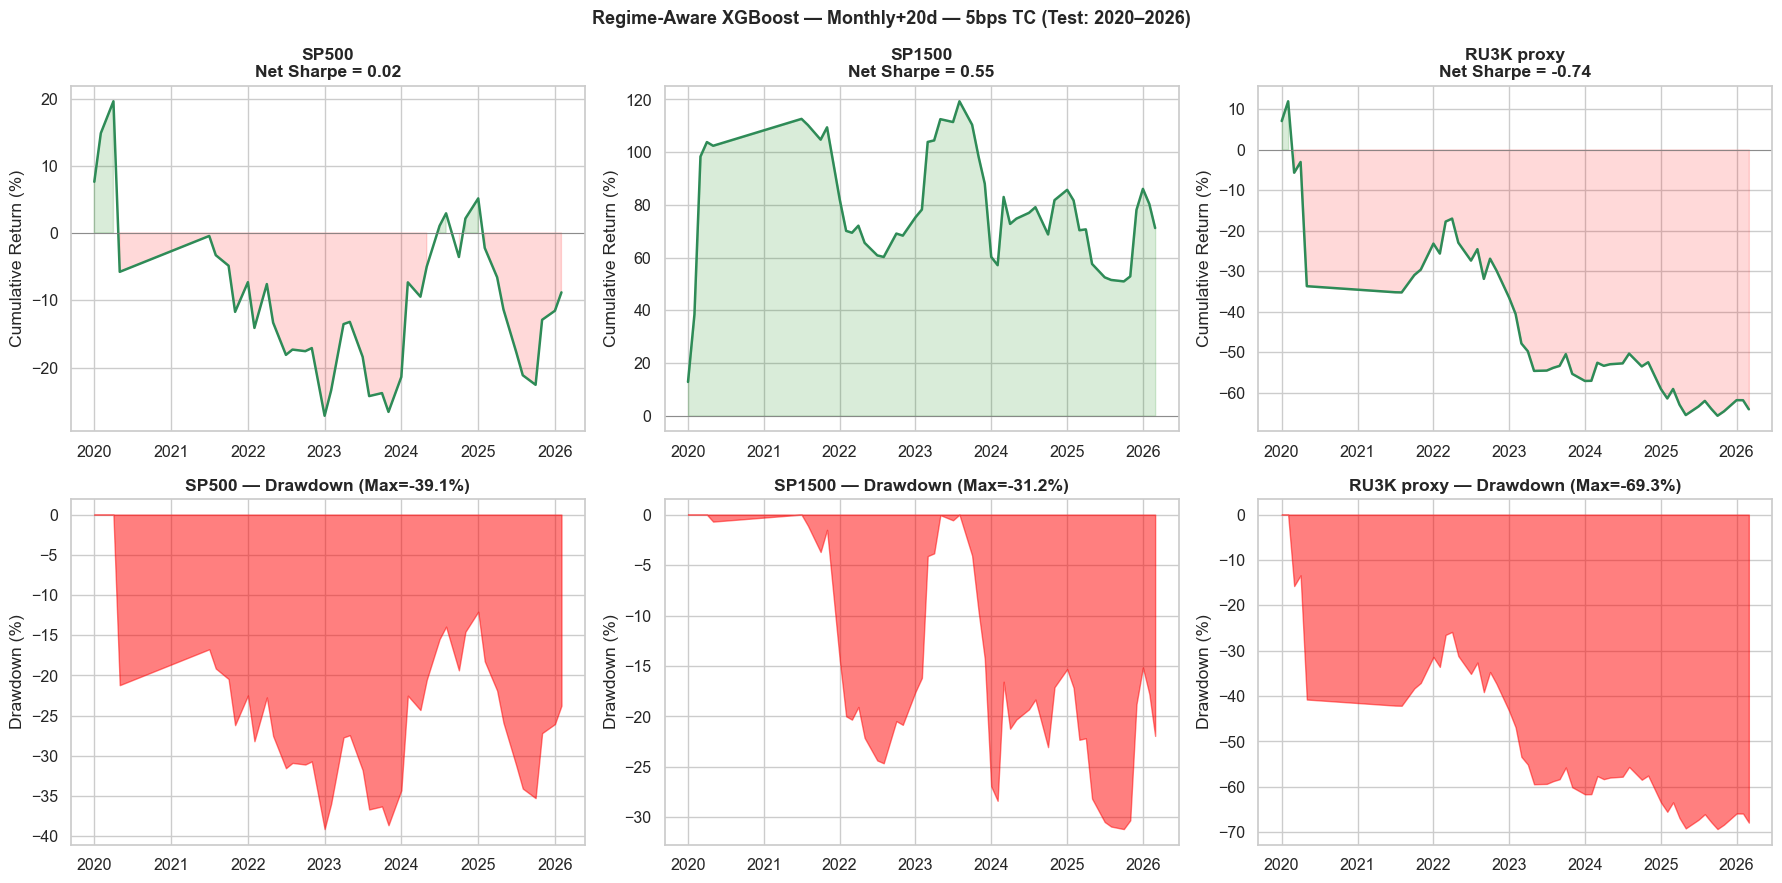

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ci, univ in enumerate(UNIVERSES):
    lbl = UNIV_LABELS[univ]
    if univ not in regime_sim:
        continue
    ret_df = regime_sim[univ]['ret_df']
    sh     = regime_sim[univ]['net']
    dates  = ret_df.index.to_timestamp()
    cum    = (1 + ret_df['net_ls']).cumprod() - 1

    ax = axes[0, ci]
    ax.plot(dates, cum * 100, 'seagreen', lw=1.8)
    ax.fill_between(dates, 0, cum * 100, where=cum > 0, alpha=0.15, color='green')
    ax.fill_between(dates, 0, cum * 100, where=cum < 0, alpha=0.15, color='red')
    ax.axhline(0, color='grey', lw=0.6)
    ax.set_title(f'{lbl}\nNet Sharpe = {sh:.2f}', fontweight='bold')
    ax.set_ylabel('Cumulative Return (%)')

    ax = axes[1, ci]
    peak = (1 + cum).expanding().max()
    dd   = ((1 + cum) / peak - 1) * 100
    ax.fill_between(dates, 0, dd, color='red', alpha=0.5)
    ax.set_title(f'{lbl} — Drawdown (Max={dd.min():.1f}%)', fontweight='bold')
    ax.set_ylabel('Drawdown (%)')

fig.suptitle('Regime-Aware XGBoost — Monthly+20d — 5bps TC (Test: 2020–2026)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'regime_model_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()

## 8.8 Three-Way Comparison: NB05 vs NB07 vs NB08

=== THREE-WAY NET SHARPE COMPARISON ===
  Universe  NB05 LightGBM Weekly+5d  NB07 ATC Weekly+20d  NB08 Regime-XGB Mon+20d
     SP500                   -0.538                2.029                    0.021
    SP1500                   -0.243                0.839                    0.545
RU3K proxy                    0.106                1.656                   -0.739


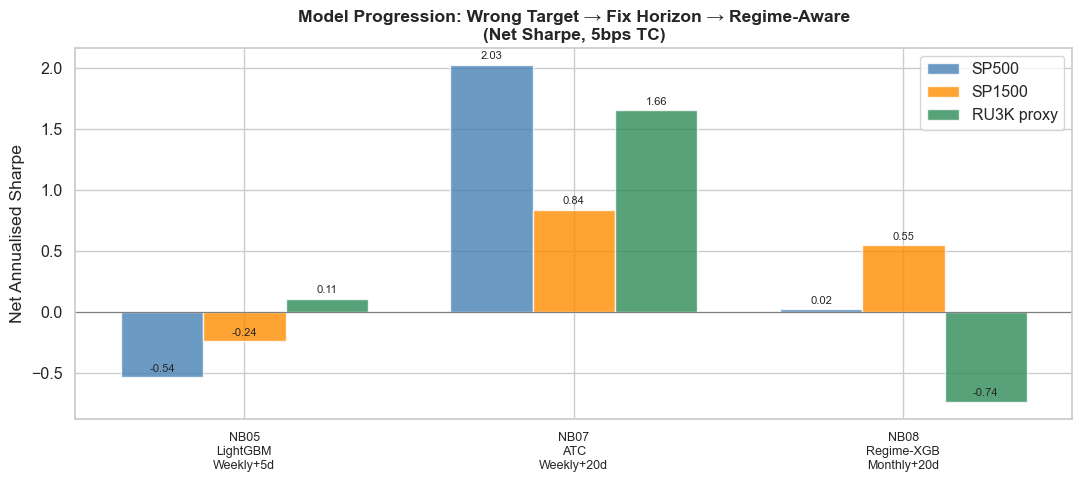

In [11]:
nb05 = pd.read_parquet(DATA_DIR / 'model_predictions.parquet')
nb05['entry_date'] = pd.to_datetime(nb05['entry_date'])

def sim_nb05(univ):
    sig = 'ensemble' if 'ensemble' in nb05.columns else 'ATCClassifierScore'
    ret_df, _ = simulate_portfolio(nb05, sig, univ, 'W', 5)
    return sharpe(ret_df['net_ls'], 52) if not ret_df.empty else np.nan

def sim_nb07(univ):
    ret_df, _ = simulate_portfolio(feat_df, 'ATCClassifierScore', univ, 'W', 20)
    return sharpe(ret_df['net_ls'], 52) if not ret_df.empty else np.nan

rows = []
for univ in UNIVERSES:
    lbl = UNIV_LABELS[univ]
    sh05 = sim_nb05(univ)
    sh07 = sim_nb07(univ)
    sh08 = regime_sim.get(univ, {}).get('net', np.nan)
    rows.append({'Universe': lbl,
                 'NB05 LightGBM Weekly+5d': round(sh05, 3),
                 'NB07 ATC Weekly+20d':     round(sh07, 3),
                 'NB08 Regime-XGB Mon+20d': round(sh08, 3)})

cmp = pd.DataFrame(rows)
print('=== THREE-WAY NET SHARPE COMPARISON ===')
print(cmp.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
labels = ['NB05\nLightGBM\nWeekly+5d', 'NB07\nATC\nWeekly+20d', 'NB08\nRegime-XGB\nMonthly+20d']
colors = ['steelblue', 'darkorange', 'seagreen']
x = np.arange(3); w = 0.25

for i, (lbl, color) in enumerate(zip(['SP500','SP1500','RU3K proxy'], colors)):
    row = cmp[cmp['Universe']==lbl].iloc[0]
    vals = [row['NB05 LightGBM Weekly+5d'],
            row['NB07 ATC Weekly+20d'],
            row['NB08 Regime-XGB Mon+20d']]
    bars = ax.bar(x + (i-1)*w, vals, w, label=lbl, color=color, alpha=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.03,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.axhline(0, color='grey', lw=0.8)
ax.set_ylabel('Net Annualised Sharpe')
ax.set_title('Model Progression: Wrong Target → Fix Horizon → Regime-Aware\n(Net Sharpe, 5bps TC)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'three_way_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print('=' * 65)
print('REGIME-AWARE MODEL — KEY FINDINGS')
print('=' * 65)

tl2 = regime_df[['entry_date','regime_ic','regime_conf']].drop_duplicates('entry_date')
pct_off = (tl2['regime_conf'] == 0).mean()
print(f'\nRegime statistics (2020-2026 test period):')
print(f'  Periods with zero confidence (no trade): {pct_off:.1%}')
print(f'  Mean regime confidence                 : {tl2["regime_conf"].mean():.2f}')
print(f'  Min rolling IC                         : {tl2["regime_ic"].min():.4f}')
print(f'  Max rolling IC                         : {tl2["regime_ic"].max():.4f}')

print(f'\nPortfolio performance (Monthly+20d, 5bps TC):')
for univ in UNIVERSES:
    sh = regime_sim.get(univ, {}).get('net', np.nan)
    print(f'  {UNIV_LABELS[univ]:8s}: Net Sharpe = {sh:.3f}')

print(f'\nIC comparison (mean over test period):')
for univ in UNIVERSES:
    sub = regime_df[regime_df[univ]].dropna(subset=[TARGET])
    ic_atc = stats.spearmanr(sub['ATCClassifierScore'], sub[TARGET])[0]
    ic_xgb = stats.spearmanr(sub['xgb_rank'],           sub[TARGET])[0]
    ic_reg = stats.spearmanr(sub['regime_scaled'],       sub[TARGET])[0]
    print(f'  {UNIV_LABELS[univ]:8s}: ATC={ic_atc:.4f}  XGB_raw={ic_xgb:.4f}  Regime_scaled={ic_reg:.4f}')
print('=' * 65)

REGIME-AWARE MODEL — KEY FINDINGS

Regime statistics (2020-2026 test period):
  Periods with zero confidence (no trade): 16.0%
  Mean regime confidence                 : 0.62
  Min rolling IC                         : -0.0997
  Max rolling IC                         : 0.0799

Portfolio performance (Monthly+20d, 5bps TC):
  SP500   : Net Sharpe = 0.021
  SP1500  : Net Sharpe = 0.545
  RU3K proxy: Net Sharpe = -0.739

IC comparison (mean over test period):
  SP500   : ATC=0.0029  XGB_raw=0.0541  Regime_scaled=-0.2092
  SP1500  : ATC=0.0377  XGB_raw=0.0578  Regime_scaled=-0.2016
  RU3K proxy: ATC=0.0516  XGB_raw=0.0290  Regime_scaled=-0.1816
